In [1]:
from src.data.data_transforms import *
from src.data.image_loader import ImageLoader
from src.training.trainer import *
from src.training.train_utils import *
from src.models.pspnet.pspnet import psp_model_optimizer
import torch
import os
from torch.utils.data import DataLoader, random_split
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image
torch.cuda.empty_cache()
from random import shuffle

%load_ext autoreload
%autoreload 2

In [2]:
# inp_size = [240, 240]
# train_set = ImageLoader("dataset", "train",
#                         get_train_transforms_common(inp_size),
#                         get_train_transforms_image())
# train_loader = DataLoader(train_set, 4, True)

# for image, mask in train_loader:
#     plt.subplot(1, 2, 1)
#     plt.imshow(image[0])
#     plt.axis("off")
#     plt.subplot(1, 2, 2)
#     plt.imshow(mask[0])
#     plt.axis("off")
#     plt.show()
#     break

In [ ]:
num_epochs = 50
h = 240
w = 240#h * 1920 // 1080
lr = 1e-2
weight_decay = 1e-4
inp_size = [h, w]
resnet_size = 50

# Initialization

Initialize the trainer class.

In [ ]:
runner = Trainer(inp_size,
                 resnet_size=resnet_size,
                 lr=lr,
                 weight_decay=weight_decay,
                 batch_size=32,
                 num_classes=11)

/home/shuvo/Work/Facial-Region-Segmentation/src/models/resnet.py:202: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path), strict=Fals

In [5]:
# Stage 1

runner.run_training_loop(num_epochs=num_epochs, load_from_disk=True)

/home/shuvo/Work/Facial-Region-Segmentation/src/training/metrics.py:65: RuntimeWarning: invalid value encountered in divide
  f1_score = np.nan_to_num((2 * precision * recall) / (precision + recall), nan=0)
/home/shuvo/Work/Facial-Region-Segmentation/src/training/metrics.py:63: RuntimeWarning: invalid value encountered in divide
  precision = np.nan_to_num(TP / (TP + FP), nan=0)
/home/shuvo/Work/Facial-Region-Segmentation/src/training/metrics.py:64: RuntimeWarning: invalid value encountered in divide
  recall = np.nan_to_num(TP / (TP + FN), nan=0)


Epoch:1
	Train Loss:0.7792
	Validation Loss:0.5987
	Train F1 Score: 0.8172
	Validation F1 Score: 0.8648
Epoch:2
	Train Loss:0.5310
	Validation Loss:0.5403
	Train F1 Score: 0.8809
	Validation F1 Score: 0.8795
Epoch:3
	Train Loss:0.4707
	Validation Loss:0.4992
	Train F1 Score: 0.8962
	Validation F1 Score: 0.8892
Epoch:4
	Train Loss:0.4399
	Validation Loss:0.4819
	Train F1 Score: 0.9037
	Validation F1 Score: 0.8939
Epoch:5
	Train Loss:0.4173
	Validation Loss:0.4610
	Train F1 Score: 0.9092
	Validation F1 Score: 0.8992
Epoch:6
	Train Loss:0.4011
	Validation Loss:0.4535
	Train F1 Score: 0.9130
	Validation F1 Score: 0.9009
Epoch:7
	Train Loss:0.3884
	Validation Loss:0.4408
	Train F1 Score: 0.9162
	Validation F1 Score: 0.9037
Epoch:8
	Train Loss:0.3789
	Validation Loss:0.4352
	Train F1 Score: 0.9185
	Validation F1 Score: 0.9063
Epoch:9
	Train Loss:0.3698
	Validation Loss:0.4291
	Train F1 Score: 0.9206
	Validation F1 Score: 0.9066
Epoch:10
	Train Loss:0.3639
	Validation Loss:0.4208
	Train F1 Sc

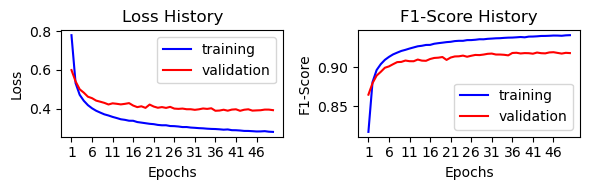

In [6]:
from src.plots.history import plot_history

plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plot_history(runner.train_loss_history, runner.validation_loss_history, "Loss", "Loss History", 5)
plt.subplot(1, 2, 2)
plot_history(runner.train_f1_history, runner.validation_f1_history, "F1-Score", "F1-Score History", 5)

plt.tight_layout()
plt.show()